In [84]:
'''
Use data from the literature to directly compare autaptic and synapse properties

'''

import numpy as np
import pandas as pandas
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# AQUA supplies the neuron/autapse model wrapper used to build Brian2 objects.
import aqua
from aqua.batchAQUA_general import batchAQUA

# Brian2 units, monitors, and network primitives are imported into the namespace.
from brian2 import *

In [85]:
# import data 

filename = 'autapse_properties_AR.csv'
df = pd.read_csv(filename)
print(df.keys())

df['Study'] = df['Author'] + " (" + df['Year'].astype(str) + ")"

print(df.head())

Index(['Author', 'Year', 'autapse', 'Epileptic', 'connection type', 'species',
       'E/I', 'duration (ms)', 'std. duration (ms)', '# events',
       'std. # events', 'driving train'],
      dtype='object')
          Author  Year  autapse  Epileptic connection type species E/I  \
0   Jiang et al.  2012     True       True      FS autapse   human   I   
1   Jiang et al.  2012     True      False      FS autapse   human   I   
2   Jiang et al.  2012    False       True           FS-FS   human   I   
3  Jiang et al.   2012    False       True           FS-FS   human   I   
4  Jiang et al.   2012    False       True           FS-PC   human   I   

   duration (ms)  std. duration (ms)  # events  std. # events   driving train  \
0          187.0                11.0      17.7            1.6  20 APs (200Hz)   
1          103.0                11.0       8.1            1.0  20 APs (200Hz)   
2           64.8                 8.6       3.2            0.6  20 APs (200Hz)   
3          117.0       

In [86]:
## CREATE a 'Study' column

# Clean up trailing whitespace in string columns if present
df['Author'] = df['Author'].str.strip()

# Convert autapse column values to standardized boolean/string representation
df['autapse_bool'] = df['autapse'].astype(str).str.upper()

# Filter groups that contain both 'TRUE' and 'FALSE'
filtered_df = df.groupby(['Author', 'Year']).filter(
    lambda group: {'TRUE', 'FALSE'}.issubset(set(group['autapse_bool']))
).drop(columns=['autapse_bool'])
filtered_df['Study'] = filtered_df['Author'] + " (" + filtered_df['Year'].astype(str) + ")"
# Print the resulting DataFrame
print(filtered_df)

print(filtered_df.keys())

print('- - - - - - - -')
print(type(filtered_df[filtered_df['Study'] == 'Li et al. (2021)']['driving train'].iloc[-1]))

          Author  Year  autapse  Epileptic connection type species E/I  \
0   Jiang et al.  2012     True       True      FS autapse   human   I   
1   Jiang et al.  2012     True      False      FS autapse   human   I   
2   Jiang et al.  2012    False       True           FS-FS   human   I   
3   Jiang et al.  2012    False       True           FS-FS   human   I   
4   Jiang et al.  2012    False       True           FS-PC   human   I   
5   Jiang et al.  2012     True      False      FS autapse     rat   I   
6   Jiang et al.  2012     True      False      FS autapse     rat   I   
7   Jiang et al.  2012    False      False           FS-PC     rat   I   
8   Jiang et al.  2012    False      False           FS-PC     rat   I   
9   Jiang et al.  2012     True       True      FS autapse     rat   I   
10  Jiang et al.  2012    False       True           FS-PC     rat   I   
11     Li et al.  2021     True      False      PC autapse   mouse   E   
12     Li et al.  2021     True      F

In [87]:
## CREATE the ratios between autapses and synapses.

# 0. Filter the df before we start.
'''
df = filtered_df[(filtered_df['Epileptic'] == True) & 
                (filtered_df['driving train'] == '20 APs (200Hz)') 
                | (filtered_df['driving train']).isna()]
'''
df = filtered_df.copy()
print(df)

# 1. Define numerical value columns to clean and calculate
value_cols = [
    'duration (ms)', 'std. duration (ms)', '# events', 'std. # events'
]

# Ensure values are clean numeric floats
for col in value_cols:
    df[col] = df[col].astype(str).str.split('(').str[0].str.strip()
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Clean autapse column
df['autapse_str'] = df['autapse'].astype(str).str.upper()

# 2. Separate into TRUE and FALSE subsets (include 'E/I' in true_df)
true_df = df[df['autapse_str'] == 'TRUE'].copy()
false_df = df[df['autapse_str'] == 'FALSE'].copy()

print('-- TRUE --')
print(true_df.head())

print('-- FALSE --')
print(false_df.head())


# 3. Merge on 'Study' (carrying over 'E/I' from the autaptic/TRUE condition)
pairwise = pd.merge(
    true_df[['Study', 'E/I', 'connection type', 'species', 'driving train', 'Epileptic'] + value_cols],
    false_df[['Study', 'Epileptic', 'species', 'connection type', 'driving train'] + value_cols],
    on=['Study', 'Epileptic', 'driving train', 'species'],
    suffixes=('_aut', '_non_aut'),
    how = 'inner'
)

print('- ------ -')
print(pairwise)

# 4. Calculate ratio (True / False) for each parameter
ratio_cols = []
for col in value_cols:
    ratio_col_name = f"{col}_ratio"
    pairwise[ratio_col_name] = pairwise[f"{col}_aut"] / pairwise[f"{col}_non_aut"]
    ratio_cols.append(ratio_col_name)

# 5. Select display columns with E/I included

display_cols = ['Study', 'E/I', 'connection type_aut', 'connection type_non_aut', 'Epileptic'] + ratio_cols
ratios_df = pairwise[display_cols]

# Optional: rename 'E/I' column for clarity
ratios_df = ratios_df.rename(columns={'E/I': 'E/I_autaptic'})

print(ratios_df)

          Author  Year  autapse  Epileptic connection type species E/I  \
0   Jiang et al.  2012     True       True      FS autapse   human   I   
1   Jiang et al.  2012     True      False      FS autapse   human   I   
2   Jiang et al.  2012    False       True           FS-FS   human   I   
3   Jiang et al.  2012    False       True           FS-FS   human   I   
4   Jiang et al.  2012    False       True           FS-PC   human   I   
5   Jiang et al.  2012     True      False      FS autapse     rat   I   
6   Jiang et al.  2012     True      False      FS autapse     rat   I   
7   Jiang et al.  2012    False      False           FS-PC     rat   I   
8   Jiang et al.  2012    False      False           FS-PC     rat   I   
9   Jiang et al.  2012     True       True      FS autapse     rat   I   
10  Jiang et al.  2012    False       True           FS-PC     rat   I   
11     Li et al.  2021     True      False      PC autapse   mouse   E   
12     Li et al.  2021     True      F

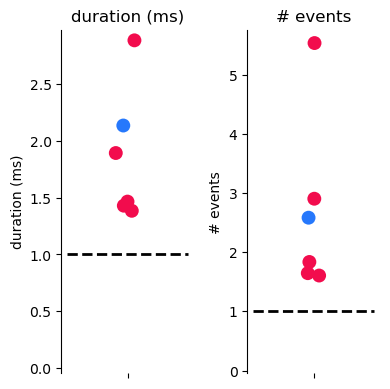

In [88]:
## Plot with 'E/I' as the hue differentiator

cols = ['duration (ms)_ratio', '# events_ratio']

fig, ax = plt.subplots(1, len(cols), figsize = (2*len(cols), 4))
sns.despine(fig = fig, bottom = True, top = True, right = True)
palette = {'E': "#2678fc", 'I': "#f20c4d"}

for n, col in enumerate(cols):
    sns.stripplot(data = ratios_df, y = col, hue = 'E/I_autaptic', palette = palette, ax = ax[n], legend = False,
                  size = 10)
    ax[n].hlines(y = 1.0, xmin = ax[n].get_xlim()[0], xmax = ax[n].get_xlim()[1], 
                 linestyle = '--', color = 'black', linewidth = 2)
    ax[n].set_title(col[:-6])
    ax[n].set_ylabel(col[:-6])
    ax[n].grid(False)
    ax[n].set_ylim(bottom = -0.05)

fig.tight_layout()
plt.savefig('./plots/Figure 2/asynch_release_EI.svg')


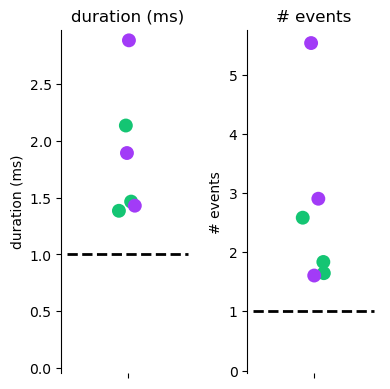

In [89]:
## Plot with 'Epileptic' as the hue differentiator

cols = ['duration (ms)_ratio', '# events_ratio']

fig, ax = plt.subplots(1, len(cols), figsize = (2*len(cols), 4))
sns.despine(fig = fig, bottom = True, top = True, right = True)
palette = {True: "#a23bf7", False: "#14c573"}

for n, col in enumerate(cols):
    sns.stripplot(data = ratios_df, y = col, hue = 'Epileptic', palette = palette, ax = ax[n], legend = False,
                  size = 10)
    ax[n].hlines(y = 1.0, xmin = ax[n].get_xlim()[0], xmax = ax[n].get_xlim()[1], 
                 linestyle = '--', color = 'black', linewidth = 2)
    ax[n].set_title(col[:-6])
    ax[n].set_ylabel(col[:-6])
    ax[n].grid(False)
    ax[n].set_ylim(bottom = -0.05)

fig.tight_layout()
plt.savefig('./plots/Figure 2/asynch_release_Epilepsy.svg')
